In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from lib.plot_style import set_style_params, set_style_params_ppt

os.makedirs("output", exist_ok=True)
%matplotlib inline

# define the style of the plot

### 毕业论文采取宽5.51,高度为4

In [2]:
# 绘图样式由 plot_style 库提供，已在首单元导入 set_style_params, set_style_params_ppt

In [3]:
# set_style_params_ppt 已从 plot_style 导入，可直接调用

# read data from .npy file and read optimization results from excel file

In [4]:
data_chord_data_path ="data/plot_data_chord.npy"
data_twist_data_path = "data/plot_data_twist.npy"
data_chord_data = np.load(data_chord_data_path).T
data_twist_data = np.load(data_twist_data_path).T
best_data = pd.read_excel("data/best_geometry.xlsx")
optimizied_chord_data = best_data[['r', 'chord']].to_numpy()
optimizied_twist_data = best_data[['r', 'twist']].to_numpy()
print(optimizied_chord_data)

[[0.0201254  0.02352523]
 [0.0252054  0.02672659]
 [0.0315579  0.02978204]
 [0.0379079  0.03186461]
 [0.0442579  0.03306251]
 [0.0506079  0.03346251]
 [0.0569579  0.03315142]
 [0.0633079  0.03221601]
 [0.0696579  0.03074309]
 [0.0760079  0.02881943]
 [0.0823586  0.02653156]
 [0.0887148  0.02396418]
 [0.0950769  0.02120353]
 [0.1014424  0.01833763]
 [0.107804   0.01545709]
 [0.1141792  0.01264158]
 [0.1173761  0.01128409]
 [0.1205864  0.0099723 ]
 [0.1238169  0.00871559]
 [0.1255     0.00808981]
 [0.12625    0.00781793]
 [0.127      0.00755055]]


# plot

## geometry of baseline

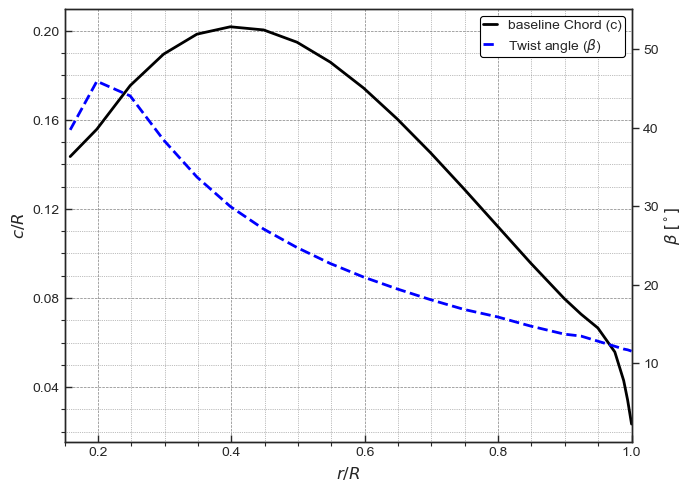

In [5]:
# apply the style to the plot
set_style_params()

# define the fig name
figure_name = "output/APC_10_7_geometry_comparison.svg"
# define the figsize
width = 6.69
length = width * 0.75

# create figure and axis objects
fig, ax = plt.subplots(figsize=((width , length))) 

# plot
ax.plot(data_chord_data[:,0] / 0.127, data_chord_data[:,1] / 0.127,'-', label=r'baseline Chord (c)', color='black',linewidth=2) # Chord Curve

# set the labels and limits
gap_c = 0.001
y_c_min = (data_chord_data[:,1].min() - gap_c) / 0.127
y_c_max = (data_chord_data[:,1].max() + gap_c) / 0.127
ax.set_xlabel(r"$r/R$")
ax.set_ylabel(r"$c/R$")
ax.set_xlim(0.15, 1)
ax.set_ylim(y_c_min, y_c_max) 

# set the tick_params
ax.tick_params(axis='both', direction='in', length=5)
plt.tight_layout()
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6))
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
# grid on 
ax.grid(True, which='both', axis='both', linestyle='--', color='gray', linewidth=0.5)
ax.minorticks_on()
ax.grid(which='minor', linestyle=':', color='gray', linewidth=0.5)

# twinx ax2
ax2 = ax.twinx()
ax2.plot(data_twist_data[:,0] / 0.127,data_twist_data[:,1], '--', label=r"Twist angle ($\beta$)", color='blue',linewidth=2) # Twist Curve
ax2.set_ylabel(r"$\beta$ [$^\circ$]")
gap_beta = 0
y_beta_min = (data_twist_data[:,].min() - gap_beta)
y_beta_max = (data_twist_data[:,].max() + gap_beta)
ax2.set_ylim(y_beta_min, y_beta_max) 


# legend settings
# Add one legend for both plots
lines = ax.get_lines() + ax2.get_lines()  # Get lines from both axes
labels = [line.get_label() for line in lines]  # Get labels for both axes
ax.legend(
    lines,labels,
    loc='best',
    framealpha=1, # transparency
    borderpad=0.2, # legend margins
    labelspacing=0.3, # tab spacing
    handlelength=1, # aspect ratio
    frameon=True,
    edgecolor='black' ,# Frame line colour
)

# Use MaxNLocator to ensure "0" is displayed without decimal
# ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # x-axis labels without decimal
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))  # y-axis labels without decimal
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # x-axis labels without decimal
ax2.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))  # second y-axis labels without decimal

# save the figure
plt.savefig(figure_name, 
            format='svg', 
            bbox_inches='tight', 
            dpi=600
            )


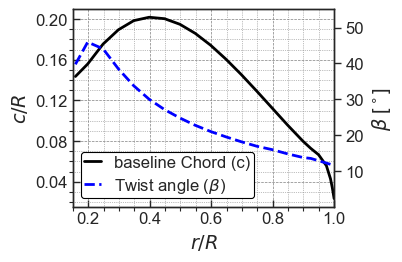

In [6]:
# apply the style to the plot
set_style_params_ppt()

# define the fig name
figure_name = "output/APC_10_7_geometry_comparison_ppt.svg"
# define the figsize
width = 6.69 / 1.8
length = width * 0.75

# create figure and axis objects
fig, ax = plt.subplots(figsize=((width , length))) 

# plot
ax.plot(data_chord_data[:,0] / 0.127, data_chord_data[:,1] / 0.127,'-', label=r'baseline Chord (c)', color='black',linewidth=2) # Chord Curve

# set the labels and limits
gap_c = 0.001
y_c_min = (data_chord_data[:,1].min() - gap_c) / 0.127
y_c_max = (data_chord_data[:,1].max() + gap_c) / 0.127
ax.set_xlabel(r"$r/R$")
ax.set_ylabel(r"$c/R$")
ax.set_xlim(0.15, 1)
ax.set_ylim(y_c_min, y_c_max) 

# set the tick_params
ax.tick_params(axis='both', direction='in', length=5)
plt.tight_layout()
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6))
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
# grid on 
ax.grid(True, which='both', axis='both', linestyle='--', color='gray', linewidth=0.5)
ax.minorticks_on()
ax.grid(which='minor', linestyle=':', color='gray', linewidth=0.5)

# twinx ax2
ax2 = ax.twinx()
ax2.plot(data_twist_data[:,0] / 0.127,data_twist_data[:,1], '--', label=r"Twist angle ($\beta$)", color='blue',linewidth=2) # Twist Curve
ax2.set_ylabel(r"$\beta$ [$^\circ$]")
gap_beta = 0
y_beta_min = (data_twist_data[:,].min() - gap_beta)
y_beta_max = (data_twist_data[:,].max() + gap_beta)
ax2.set_ylim(y_beta_min, y_beta_max) 


# legend settings
# Add one legend for both plots
lines = ax.get_lines() + ax2.get_lines()  # Get lines from both axes
labels = [line.get_label() for line in lines]  # Get labels for both axes
ax.legend(
    lines,labels,
    loc='best',
    framealpha=1, # transparency
    borderpad=0.2, # legend margins
    labelspacing=0.3, # tab spacing
    handlelength=1, # aspect ratio
    frameon=True,
    edgecolor='black' ,# Frame line colour
)

# Use MaxNLocator to ensure "0" is displayed without decimal
# ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # x-axis labels without decimal
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))  # y-axis labels without decimal
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # x-axis labels without decimal
ax2.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))  # second y-axis labels without decimal







# save the figure
plt.savefig(figure_name, 
            format='svg', 
            bbox_inches='tight', 
            dpi=600
            )


## for BSpline fitting

In [7]:
BSpline_fitting_data = pd.read_csv('data/Bspline.csv')
print(BSpline_fitting_data)

    Unnamed: 0         0          1         2
0            0  0.020125  55.093553  0.023128
1            1  0.025205  49.679044  0.024208
2            2  0.031558  43.689038  0.025068
3            3  0.037908  38.504398  0.025429
4            4  0.044258  34.053857  0.025342
5            5  0.050608  30.268673  0.024856
6            6  0.056958  27.080103  0.024022
7            7  0.063308  24.419404  0.022890
8            8  0.069658  22.217835  0.021509
9            9  0.076008  20.406652  0.019931
10          10  0.082359  18.916965  0.018204
11          11  0.088715  17.679247  0.016377
12          12  0.095077  16.625060  0.014501
13          13  0.101442  15.686040  0.012626
14          14  0.107804  14.794095  0.010805
15          15  0.114179  13.877471  0.009083
16          16  0.117376  13.387423  0.008274
17          17  0.120586  12.863122  0.007508
18          18  0.123817  12.293979  0.006789
19          19  0.125500  11.977936  0.006437
20          20  0.126250  11.83233

In [8]:
print(type(BSpline_fitting_data))
data_Bspline = BSpline_fitting_data.to_numpy()
data_Bspline = data_Bspline[:,1:]
print(data_Bspline)

<class 'pandas.core.frame.DataFrame'>
[[2.01254000e-02 5.50935528e+01 2.31281488e-02]
 [2.52054000e-02 4.96790437e+01 2.42084164e-02]
 [3.15579000e-02 4.36890379e+01 2.50683109e-02]
 [3.79079000e-02 3.85043980e+01 2.54293029e-02]
 [4.42579000e-02 3.40538571e+01 2.53418902e-02]
 [5.06079000e-02 3.02686727e+01 2.48561272e-02]
 [5.69579000e-02 2.70801026e+01 2.40220687e-02]
 [6.33079000e-02 2.44194041e+01 2.28897692e-02]
 [6.96579000e-02 2.22178348e+01 2.15092834e-02]
 [7.60079000e-02 2.04066524e+01 1.99306657e-02]
 [8.23586000e-02 1.89169652e+01 1.82037743e-02]
 [8.87148000e-02 1.76792469e+01 1.63772357e-02]
 [9.50769000e-02 1.66250596e+01 1.45009432e-02]
 [1.01442400e-01 1.56860401e+01 1.26259037e-02]
 [1.07804000e-01 1.47940948e+01 1.08046237e-02]
 [1.14179200e-01 1.38774710e+01 9.08275076e-03]
 [1.17376100e-01 1.33874227e+01 8.27411887e-03]
 [1.20586400e-01 1.28631223e+01 7.50750976e-03]
 [1.23816900e-01 1.22939793e+01 6.78854819e-03]
 [1.25500000e-01 1.19779358e+01 6.43701163e-03]
 [

In [9]:
from scipy.interpolate import BSpline
# define Knots Vector
degree = 3  # BSpline degree
num_points = 4

num_knots = num_points + degree + 1  # the length of knots vector
knots = np.concatenate(([0] * degree,[0.3984874,0.89904882,], [1] * degree))
# create  B spline object
bspline = BSpline(knots,[0.0198272, 0.03303,   0.01493,   0.00697], degree)

# generate curves
r_fine = np.linspace(0, 1, 500)  # more x points
# chord_spline = bspline(r_fine)
chord_spline = bspline(data_chord_data[:,0] / 0.127)


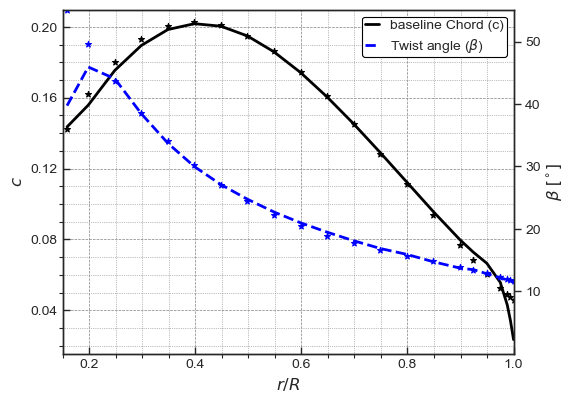

In [10]:
# apply the style to the plot
set_style_params()

# define the fig name
figure_name = "output/APC_10_7_geometry_BSpline.png"
# define the figsize
# width = 6.69
width = 5.51
length = width * 0.75
# length = width * 0.75

# create figure and axis objects
fig, ax = plt.subplots(figsize=((width , length))) 

# plot
# ax.scatter(data_Bspline[:,0] / 0.127, data_Bspline[:,2] / 0.127, label=r'B-Spline chord', color='black', s=10, marker='*') # BSpline fitting

# ax.plot(data_chord_data[:,0] / 0.127, data_chord_data[:,1] / 0.127,'-', label=r'baseline Chord (c)', color='black',linewidth=2) # Chord Curve
ax.scatter(data_chord_data[:,0] / 0.127, chord_spline / 0.127, label=r'B-Spline chord', color='black', s=20, marker='*') # BSpline fitting
ax.plot(data_chord_data[:,0] / 0.127, data_chord_data[:,1] / 0.127,'-', label=r'baseline Chord (c)', color='black',linewidth=2) # Chord Curve
# set the labels and limits
gap_c = 0.001
y_c_min = (data_chord_data[:,1].min() - gap_c) / 0.127
y_c_max = (data_chord_data[:,1].max() + gap_c) / 0.127
# y_c_min = (data_chord_data[:,1].min() - gap_c)
# y_c_max = (data_chord_data[:,1].max() + gap_c)
ax.set_xlabel(r"$r/R$")
ax.set_ylabel(r"$c$")
ax.set_xlim(0.15, 1)
# ax.set_xlim(0.15 * 0.127, 0.128)
ax.set_ylim(y_c_min, y_c_max) 

# set the tick_params
ax.tick_params(axis='both', direction='in', length=5)
plt.tight_layout()
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6))
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
# grid on 
ax.grid(True, which='both', axis='both', linestyle='--', color='gray', linewidth=0.5)
ax.minorticks_on()
ax.grid(which='minor', linestyle=':', color='gray', linewidth=0.5)

# twinx ax2
ax2 = ax.twinx()
ax2.scatter(data_Bspline[:,0] / 0.127, data_Bspline[:,1], label=r'B-Spline Twistt', color='blue', s=20, marker='*') # BSpline fitting
ax2.plot(data_twist_data[:,0] / 0.127,data_twist_data[:,1], '--', label=r"Twist angle ($\beta$)", color='blue',linewidth=2) # Twist Curve
ax2.set_ylabel(r"$\beta$ [$^\circ$]")
gap_beta = 0
y_beta_min = (data_twist_data[:,].min() - gap_beta)
y_beta_max = (data_twist_data[:,].max() + gap_beta)
ax2.set_ylim(y_beta_min, y_beta_max) 


# legend settings
# Add one legend for both plots
lines = ax.get_lines() + ax2.get_lines()  # Get lines from both axes
labels = [line.get_label() for line in lines]  # Get labels for both axes
ax.legend(
    lines,labels,
    loc='best',
    framealpha=1, # transparency
    borderpad=0.2, # legend margins
    labelspacing=0.3, # tab spacing
    handlelength=1, # aspect ratio
    frameon=True,
    edgecolor='black' ,# Frame line colour
)

# Use MaxNLocator to ensure "0" is displayed without decimal
# ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # x-axis labels without decimal
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))  # y-axis labels without decimal
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # x-axis labels without decimal
ax2.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))  # second y-axis labels without decimal

# save the figure
plt.savefig(figure_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )


### 手动添加图例

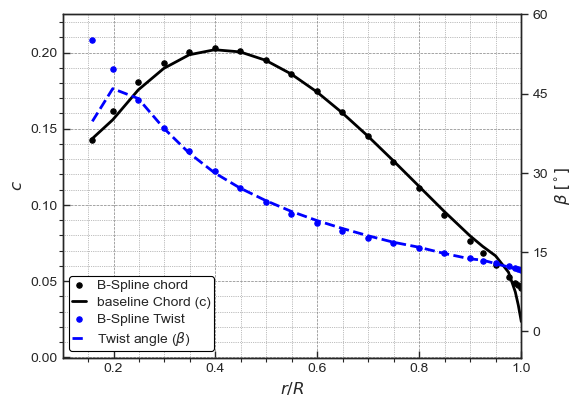

In [16]:
# apply the style to the plot
set_style_params()

# define the fig name
figure_name = "output/APC_10_7_geometry_BSpline.png"
# define the figsize
width = 5.51
length = width * 0.75

# create figure and axis objects
fig, ax = plt.subplots(figsize=(width , length)) 

# plot
scatter1 = ax.scatter(data_chord_data[:,0] / 0.127, chord_spline / 0.127, color='black', s=15, marker='o')  # B-Spline fitting
line1, = ax.plot(data_chord_data[:,0] / 0.127, data_chord_data[:,1] / 0.127, '-', color='black', linewidth=2)  # Chord Curve

# set the labels and limits
gap_c = 0.003
y_c_min = (data_chord_data[:,1].min() - gap_c) / 0.127
y_c_max = (data_chord_data[:,1].max() + gap_c) / 0.127
ax.set_xlabel(r"$r/R$")
ax.set_ylabel(r"$c$")
ax.set_xlim(0.10, 1)
ax.set_ylim(y_c_min, y_c_max)

# set the tick_params
ax.tick_params(axis='both', direction='in', length=5)
plt.tight_layout()
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6))
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
# grid on 
ax.grid(True, which='both', axis='both', linestyle='--', color='gray', linewidth=0.5)
ax.minorticks_on()
ax.grid(which='minor', linestyle=':', color='gray', linewidth=0.5)

# twinx ax2
ax2 = ax.twinx()
scatter2 = ax2.scatter(data_Bspline[:,0] / 0.127, data_Bspline[:,1], color='blue', s=15, marker='o')  # B-Spline Twist
line2, = ax2.plot(data_twist_data[:,0] / 0.127, data_twist_data[:,1], '--', color='blue', linewidth=2)  # Twist Curve
ax2.set_ylabel(r"$\beta$ [$^\circ$]")

gap_beta = 5
y_beta_min = (data_twist_data[:,].min() - gap_beta)
y_beta_max = (data_twist_data[:,].max() + gap_beta)
ax2.set_ylim(y_beta_min, y_beta_max) 

# 1. 手动添加图例
# 为 scatter 和 line 图形对象手动指定标签
# 这里直接将 scatter 和 plot 对象和对应标签传递给 legend
ax.legend(
    [scatter1, line1,scatter2, line2],  # 添加到图例中的 scatter 和 plot 对象
    [r'B-Spline chord', r'baseline Chord (c)',r'B-Spline Twist', r'Twist angle ($\beta$)'],  # 对应的标签
    loc='lower left',  # 图例的位置
    framealpha=1,  # 图例透明度
    borderpad=0.2,  # 图例的边距
    labelspacing=0.3,  # 标签间距
    handlelength=1,  # 图例中线条的长度
    frameon=True,  # 是否显示图例框
    edgecolor='black'  # 图例框的边框颜色
)

# ax2.legend(
#     [scatter2, line2],  # 添加到图例中的 scatter 和 plot 对象
#     [r'B-Spline Twist', r'Twist angle ($\beta$)'],  # 对应的标签
#     loc='upper right',  # 图例的位置
#     framealpha=1,  # 图例透明度
#     borderpad=0.2,  # 图例的边距
#     labelspacing=0.3,  # 标签间距
#     handlelength=1,  # 图例中线条的长度
#     frameon=True,  # 是否显示图例框
#     edgecolor='black'  # 图例框的边框颜色
# )

# Use MaxNLocator to ensure "0" is displayed without decimal
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))  # y-axis labels without decimal
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # x-axis labels without decimal
ax2.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))  # second y-axis labels without decimal

# save the figure
plt.savefig(figure_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )
